# Reprodução didática de DDPM e DDIM em MNIST

Este notebook reproduz o núcleo algorítmico de **Denoising Diffusion Probabilistic Models** (Ho, Jain e Abbeel, 2020) e **Denoising Diffusion Implicit Models** (Song, Meng e Ermon, 2021). O tutorial e o survey da pasta `articles` são usados como apoio teórico.

O objetivo é verificar o processo direto, treinar o objetivo simplificado $L_{simple}$ e comparar a amostragem DDPM com a DDIM determinística. MNIST e uma rede pequena substituem CIFAR-10/LSUN para que o experimento possa ser executado durante um seminário; portanto, os valores de FID e Inception Score dos artigos **não** são reproduzidos.

## 1. Ambiente e configuração

Execute o notebook pelo ambiente criado com `uv sync`. O modo rápido é o padrão; mude `QUICK_RUN` para `False` para usar todo o MNIST e mais épocas.

In [50]:
import math
import random
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from torchvision.utils import make_grid

SEED = 42
QUICK_RUN = False
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
T = 1_000
EPOCHS = 20 if QUICK_RUN else 50
TRAIN_SAMPLES = 5_000 if QUICK_RUN else 60_000
BATCH_SIZE = 128

ROOT = Path.cwd().parents[1] if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = ROOT / "seminar_1" / "data" / "mnist" / "source"
CHECKPOINT = ROOT / "seminar_1" / "data" / "mnist" / "models" / "ddpm_mnist.pt"
CHECKPOINT.parent.mkdir(parents=True, exist_ok=True)
print(f"device={DEVICE}, T={T}, amostras={TRAIN_SAMPLES}, épocas={EPOCHS}")

device=cpu, T=1000, amostras=60000, épocas=50


## 2. Dados

As imagens são normalizadas para $[-1, 1]$, mesma faixa usada pela saída do processo de geração.

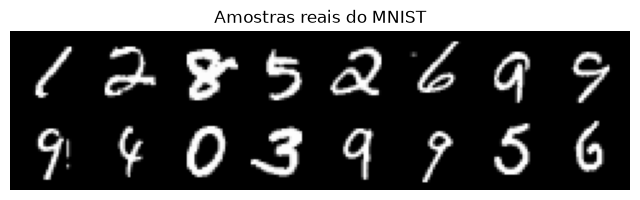

In [51]:
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
train_data = datasets.MNIST(DATA_DIR, train=True, download=True, transform=transform)
if TRAIN_SAMPLES < len(train_data):
    indices = torch.randperm(len(train_data), generator=torch.Generator().manual_seed(SEED))[:TRAIN_SAMPLES]
    train_data = Subset(train_data, indices)
train_loader = DataLoader(
    train_data, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=DEVICE.type == "cuda"
)

images, _ = next(iter(train_loader))
grid = make_grid((images[:16] + 1) / 2, nrow=8)
plt.figure(figsize=(8, 2.2))
plt.imshow(grid.permute(1, 2, 0).clip(0, 1))
plt.axis("off")
plt.title("Amostras reais do MNIST")
plt.show()

## 3. Processo direto $q(x_t \mid x_0)$

Com $\alpha_t=1-\beta_t$ e $\bar\alpha_t=\prod_{s=1}^{t}\alpha_s$, qualquer estado ruidoso pode ser obtido diretamente:

$$x_t=\sqrt{\bar\alpha_t}x_0+\sqrt{1-\bar\alpha_t}\epsilon, \qquad \epsilon\sim\mathcal{N}(0,I).$$

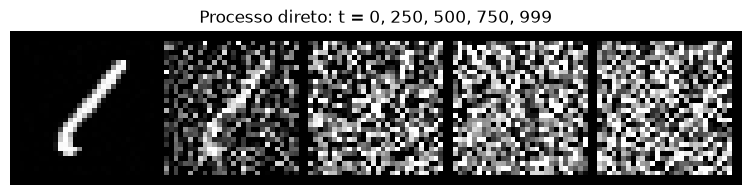

In [52]:
schedule_scale = 1_000 / T
betas = torch.linspace(schedule_scale * 1e-4, schedule_scale * 2e-2, T, device=DEVICE)
alphas = 1 - betas
alpha_bars = torch.cumprod(alphas, dim=0)
alpha_bars_previous = F.pad(alpha_bars[:-1], (1, 0), value=1.0)
posterior_variance = betas * (1 - alpha_bars_previous) / (1 - alpha_bars)

def extract(values, timesteps, shape):
    return values[timesteps].view(timesteps.shape[0], *((1,) * (len(shape) - 1)))

def q_sample(x0, timesteps, noise=None):
    noise = torch.randn_like(x0) if noise is None else noise
    mean = extract(alpha_bars.sqrt(), timesteps, x0.shape) * x0
    std = extract((1 - alpha_bars).sqrt(), timesteps, x0.shape)
    return mean + std * noise, noise

# Verificação mínima das invariantes usadas por treino e amostragem.
assert alpha_bars.shape == (T,) and torch.all(alpha_bars[1:] < alpha_bars[:-1])
probe, _ = q_sample(images[:4].to(DEVICE), torch.tensor([0, T // 3, 2 * T // 3, T - 1], device=DEVICE))
assert probe.shape == images[:4].shape

steps = torch.tensor([0, T // 4, T // 2, 3 * T // 4, T - 1], device=DEVICE)
x0 = images[:1].to(DEVICE).repeat(len(steps), 1, 1, 1)
noisy, _ = q_sample(x0, steps)
grid = make_grid((noisy.cpu() + 1) / 2, nrow=len(steps))
plt.figure(figsize=(10, 2))
plt.imshow(grid.permute(1, 2, 0).clip(0, 1))
plt.axis("off")
plt.title("Processo direto: t = " + ", ".join(map(str, steps.tolist())))
plt.show()

## 4. Preditor de ruído

A rede recebe $x_t$ e o passo $t$. Ela é deliberadamente pequena para o seminário, mas mantém condicionamento temporal senoidal e conexões residuais entre resoluções.

In [53]:
class SinusoidalTimeEmbedding(nn.Module):
    def __init__(self, size=32):
        super().__init__()
        half = size // 2
        self.register_buffer("frequencies", torch.exp(-math.log(10_000) * torch.arange(half) / (half - 1)))

    def forward(self, timesteps):
        angles = timesteps[:, None].float() * self.frequencies[None]
        return torch.cat((angles.sin(), angles.cos()), dim=1)

class TinyDenoiser(nn.Module):
    def __init__(self):
        super().__init__()
        self.time = nn.Sequential(SinusoidalTimeEmbedding(), nn.Linear(32, 64), nn.SiLU())
        self.time1 = nn.Linear(64, 32)
        self.time2 = nn.Linear(64, 64)
        self.time3 = nn.Linear(64, 64)
        self.down1 = nn.Conv2d(1, 32, 3, padding=1)
        self.down2 = nn.Conv2d(32, 64, 4, stride=2, padding=1)
        self.down3 = nn.Conv2d(64, 64, 4, stride=2, padding=1)
        self.up1 = nn.ConvTranspose2d(64, 64, 4, stride=2, padding=1)
        self.up2 = nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1)
        self.output = nn.Conv2d(32, 1, 3, padding=1)
        self.norm1 = nn.GroupNorm(8, 32)
        self.norm2 = nn.GroupNorm(8, 64)
        self.norm3 = nn.GroupNorm(8, 64)
        self.norm4 = nn.GroupNorm(8, 64)
        self.norm5 = nn.GroupNorm(8, 32)

    def forward(self, x, timesteps):
        time_embedding = self.time(timesteps)
        h1 = F.silu(self.norm1(self.down1(x) + self.time1(time_embedding)[:, :, None, None]))
        h2 = F.silu(self.norm2(self.down2(h1) + self.time2(time_embedding)[:, :, None, None]))
        h3 = F.silu(self.norm3(self.down3(h2) + self.time3(time_embedding)[:, :, None, None]))
        h = F.silu(self.norm4(self.up1(h3) + h2))
        h = F.silu(self.norm5(self.up2(h) + h1))
        return self.output(h)

model = TinyDenoiser().to(DEVICE)
parameter_count = sum(parameter.numel() for parameter in model.parameters())
assert model(torch.zeros(2, 1, 28, 28, device=DEVICE), torch.tensor([0, T - 1], device=DEVICE)).shape == (2, 1, 28, 28)
print(f"{parameter_count:,} parâmetros treináveis")

210,465 parâmetros treináveis


## 5. Treino com $L_{simple}$

A cada lote sorteamos $t$ e $\epsilon$ e minimizamos $\lVert\epsilon-\epsilon_\theta(x_t,t)\rVert_2^2$, conforme o Algoritmo 1 do DDPM. Um checkpoint evita repetir o treino ao reabrir o notebook. Para treinar novamente, apague `ddpm_mnist.pt`.

In [54]:
losses = []
if CHECKPOINT.exists():
    model.load_state_dict(torch.load(CHECKPOINT, map_location=DEVICE, weights_only=True))
    print(f"Checkpoint carregado de {CHECKPOINT}")
else:
    optimizer = torch.optim.AdamW(model.parameters(), lr=2e-4)
    model.train()
    for epoch in range(EPOCHS):
        total_loss = 0.0
        for x0, _ in train_loader:
            x0 = x0.to(DEVICE, non_blocking=True)
            timesteps = torch.randint(T, (x0.shape[0],), device=DEVICE)
            xt, noise = q_sample(x0, timesteps)
            loss = F.mse_loss(model(xt, timesteps), noise)
            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * x0.shape[0]
        epoch_loss = total_loss / len(train_loader.dataset)
        losses.append(epoch_loss)
        print(f"época {epoch + 1:02d}/{EPOCHS}: loss={epoch_loss:.4f}")
    torch.save(model.state_dict(), CHECKPOINT)

if losses:
    plt.plot(range(1, len(losses) + 1), losses, marker="o")
    plt.xlabel("Época")
    plt.ylabel("MSE")
    plt.title("Objetivo simplificado do DDPM")
    plt.grid(alpha=0.3)
    plt.show()

Checkpoint carregado de /home/matheus/Documentos/mestrado/repositories/matheus-983-tp558/seminar_1/notebooks/ddpm_mnist.pt


## 6. Amostragem DDPM

O processo começa em $x_T\sim\mathcal{N}(0,I)$ e percorre todos os passos de trás para frente. Aqui usamos a variância posterior $\tilde\beta_t$.

In [55]:
@torch.inference_mode()
def sample_ddpm(model, sample_count=16):
    model.eval()
    x = torch.randn(sample_count, 1, 28, 28, device=DEVICE)
    for step in reversed(range(T)):
        timesteps = torch.full((sample_count,), step, device=DEVICE, dtype=torch.long)
        predicted_noise = model(x, timesteps)
        mean = (x - betas[step] / torch.sqrt(1 - alpha_bars[step]) * predicted_noise) / torch.sqrt(alphas[step])
        if step > 0:
            x = mean + posterior_variance[step].sqrt() * torch.randn_like(x)
        else:
            x = mean
    return x.clamp(-1, 1)

start = time.perf_counter()
ddpm_samples = sample_ddpm(model)
ddpm_seconds = time.perf_counter() - start
print(f"DDPM: {T} avaliações da rede em {ddpm_seconds:.2f} s")

DDPM: 1000 avaliações da rede em 3.80 s


## 7. Amostragem DDIM

O DDIM reutiliza exatamente a mesma rede e pode saltar passos. O parâmetro $\eta$ controla a estocasticidade: $\eta=0$ produz a trajetória determinística e $\eta=1$ é mais robusto aos erros deste preditor pequeno. Usamos 50 passos e $\eta=1$ por padrão; troque para zero para demonstrar o regime implícito determinístico.

In [56]:
@torch.inference_mode()
def sample_ddim(model, sample_count=16, sampling_steps=40, eta=0.0):
    model.eval()
    x = torch.randn(sample_count, 1, 28, 28, device=DEVICE)
    schedule = torch.linspace(T - 1, 0, sampling_steps, device=DEVICE).long()
    assert sampling_steps <= T and torch.all(schedule[:-1] > schedule[1:])

    for index, step in enumerate(schedule):
        timesteps = torch.full((sample_count,), step, device=DEVICE, dtype=torch.long)
        predicted_noise = model(x, timesteps)
        alpha_bar = alpha_bars[step]
        previous_alpha_bar = alpha_bars[schedule[index + 1]] if index + 1 < len(schedule) else torch.tensor(1.0, device=DEVICE)
        predicted_x0 = (x - torch.sqrt(1 - alpha_bar) * predicted_noise) / torch.sqrt(alpha_bar)
        sigma = eta * torch.sqrt((1 - previous_alpha_bar) / (1 - alpha_bar) * (1 - alpha_bar / previous_alpha_bar))
        direction = torch.sqrt(torch.clamp(1 - previous_alpha_bar - sigma.square(), min=0)) * predicted_noise
        noise = torch.randn_like(x) if eta > 0 else 0.0
        x = torch.sqrt(previous_alpha_bar) * predicted_x0 + direction + sigma * noise
    return x.clamp(-1, 1)

DDIM_STEPS = 50 if QUICK_RUN else 100
DDIM_ETA = 1.0
start = time.perf_counter()
ddim_samples = sample_ddim(model, sampling_steps=DDIM_STEPS, eta=DDIM_ETA)
ddim_seconds = time.perf_counter() - start
print(f"DDIM (η={DDIM_ETA:g}): {DDIM_STEPS} avaliações da rede em {ddim_seconds:.2f} s")

DDIM (η=1): 100 avaliações da rede em 0.40 s


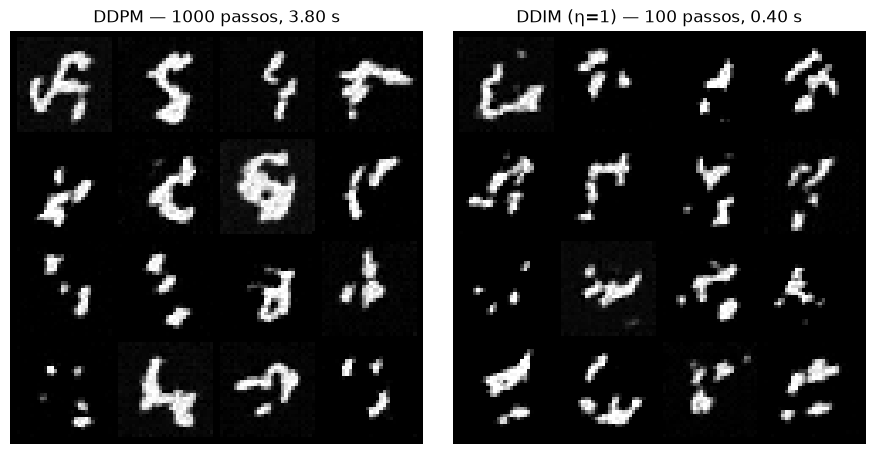

Aceleração observada nesta execução: 9.54x


In [57]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4.5))
for axis, samples, title in [
    (axes[0], ddpm_samples, f"DDPM — {T} passos, {ddpm_seconds:.2f} s"),
    (axes[1], ddim_samples, f"DDIM (η={DDIM_ETA:g}) — {DDIM_STEPS} passos, {ddim_seconds:.2f} s"),
]:
    grid = make_grid((samples.cpu() + 1) / 2, nrow=4)
    axis.imshow(grid.permute(1, 2, 0).clip(0, 1))
    axis.set_title(title)
    axis.axis("off")
plt.tight_layout()
plt.show()
print(f"Aceleração observada nesta execução: {ddpm_seconds / ddim_seconds:.2f}x")

## 8. Discussão

- O processo direto confirma visualmente a perda gradual de informação prevista por $q(x_t\mid x_0)$.
- O treino implementa o objetivo de predição de ruído do DDPM sem alterar sua forma matemática.
- O DDIM reduz o número de avaliações da mesma rede; a aceleração medida depende do hardware.
- A qualidade fica abaixo dos artigos por usarmos menos dados, passos, épocas e uma arquitetura muito menor. Comparar FID não seria válido neste recorte.

### Artigos locais

1. Ho, J.; Jain, A.; Abbeel, P. *Denoising Diffusion Probabilistic Models*. NeurIPS, 2020.
2. Song, J.; Meng, C.; Ermon, S. *Denoising Diffusion Implicit Models*. ICLR, 2021.
3. Ghojogh, B.; Ghodsi, A. *Diffusion Models: Tutorial and Survey*. 2024.
4. Yang, L. et al. *Diffusion Models: A Comprehensive Survey of Methods and Applications*. ACM Computing Surveys, 2023.